<a href="https://colab.research.google.com/github/nykollg/TRABAJO-GRADO/blob/main/regresi_n_lineal_multiple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving DBF_ENCV_591_3.CSV to DBF_ENCV_591_3.CSV


In [ ]:
import io
import pandas as pd
import matplotlib.pyplot as plt
bites = io.BytesIO(uploaded['DBF_ENCV_591_3.CSV'])
tabla_conv = pd.read_csv(bites, sep = ";", index_col= 0, encoding = 'latin-1')
tabla_conv.head(4)

,SECUENCIA_ENCUESTA,SECUENCIA_P,ORDEN,FEX_C,P1079,P9010,P9025,P9025S1,P9025S2,P5230,...,P3525S1,P3525S2,P3525S3,P3525S4,P3525S5,P3525S6,P3525S7,P3525S8,prob_iams,prob_ias
DIRECTORIO,,,,,,,,,,,,,,,,,,,,,
7787900,1,1,1,143.618606,1,1,NaN,2,2,1,...,NaN,1.0,NaN,1.0,NaN,1.0,NaN,NaN,0.7268,0.0001
7787901,1,1,1,273.731538,1,1,NaN,2,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.9343,0.0051
7787902,1,1,1,367.458347,1,1,NaN,2,2,2,...,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,0.0000,0.0000
7787903,1,1,1,449.276475,1,2,NaN,1,2,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1077,0.0000


In [ ]:
tabla_conv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88328 entries, 7787900 to 7910108
Columns: 141 entries, SECUENCIA_ENCUESTA to prob_ias
dtypes: float64(75), int64(66)
memory usage: 95.7 MB


In [ ]:
tabla_conv.columns

Index(['SECUENCIA_ENCUESTA', 'SECUENCIA_P', 'ORDEN', 'FEX_C', 'P1079', 'P9010',
       'P9025', 'P9025S1', 'P9025S2', 'P5230',
       ...
       'P3525S1', 'P3525S2', 'P3525S3', 'P3525S4', 'P3525S5', 'P3525S6',
       'P3525S7', 'P3525S8', 'prob_iams', 'prob_ias'],
      dtype='object', length=141)

In [ ]:
###NNNNNN
####eliminar vacios
tabla_conv['P3202S8'] = tabla_conv['P3202S8'].fillna(0)
tabla_conv['P3202S10'] = tabla_conv['P3202S10'].fillna(0)

tabla_conv.to_csv("DBF_ENCV_591_3_modificado.csv", index=False)

tabla_conv.iloc[:, [91, 93]].head()

,P3202S8,P3202S10
DIRECTORIO,,
7787900,0.0,1.0
7787901,0.0,0.0
7787902,0.0,1.0
7787903,0.0,1.0
7787904,0.0,0.0


In [ ]:
dummies = tabla_conv[['P5230', 'P9025S1', 'P9090', 'P1072S1', 'P1077S2', 'P1076', 'P1075', 'P3353', 'P3516S7']]

In [ ]:
dummi_calidad = pd.get_dummies(dummies, columns=[ "P5230", "P9025S1", "P9090", "P1077S2", "P1076", "P1075","P3353", "P3516S7" ], dtype = float)
dummi_calidad.head(5)

,P1072S1,P5230_1,P5230_2,P9025S1_1,P9025S1_2,P9090_1,P9090_2,P9090_3,P1077S2_1,P1077S2_2,...,P1075_1,P1075_2,P3353_1,P3353_2,P3353_3,P3353_4,P3353_5,P3516S7_1,P3516S7_2,P3516S7_3
DIRECTORIO,,,,,,,,,,,,,,,,,,,,,
7787900,7,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
7787901,7,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7787902,2,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
7787903,7,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7787904,7,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


Inés

In [ ]:
#tabla variables no dummies
no_dummies = tabla_conv[['P1072S1', 'P1913S2', 'P1913S3']]

In [ ]:
tabla_final = pd.concat([no_dummies, dummi_calidad], axis=1)
tabla_final.head(4)
tabla_final.columns

Index(['P1072S1', 'P1913S2', 'P1913S3', 'P1072S1', 'P5230_1', 'P5230_2',
       'P9025S1_1', 'P9025S1_2', 'P9090_1', 'P9090_2', 'P9090_3', 'P1077S2_1',
       'P1077S2_2', 'P1076_1.0', 'P1076_2.0', 'P1076_3.0', 'P1076_4.0',
       'P1075_1', 'P1075_2', 'P3353_1', 'P3353_2', 'P3353_3', 'P3353_4',
       'P3353_5', 'P3516S7_1', 'P3516S7_2', 'P3516S7_3'],
      dtype='object')

In [ ]:
tabla_final = tabla_final.reset_index(drop=True)
tabla_final.head(4)

,P1072S1,P1913S2,P1913S3,P1072S1,P5230_1,P5230_2,P9025S1_1,P9025S1_2,P9090_1,P9090_2,...,P1075_1,P1075_2,P3353_1,P3353_2,P3353_3,P3353_4,P3353_5,P3516S7_1,P3516S7_2,P3516S7_3
0,7,15,15,7,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,7,10,10,7,1.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,2,10,15,2,0.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,7,0,20,7,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
# tabla_final = tabla_final[~tabla_final.index.duplicated(keep='first')]
tabla_final1 = tabla_final.iloc[:, [i for i in range(tabla_final.shape[1]) if i != 3]]
tabla_final1.head(4)

,P1072S1,P1913S2,P1913S3,P5230_1,P5230_2,P9025S1_1,P9025S1_2,P9090_1,P9090_2,P9090_3,...,P1075_1,P1075_2,P3353_1,P3353_2,P3353_3,P3353_4,P3353_5,P3516S7_1,P3516S7_2,P3516S7_3
0,7,15,15,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,7,10,10,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,2,10,15,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,7,0,20,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
tabla_final1.index = range(len(tabla_final))


In [ ]:
tabla_final1["P1072S1"]

,P1072S1
0,7
1,7
2,2
3,7
4,7
...,...
88323,8
88324,7
88325,4
88326,2


In [ ]:
tabla_final2 = tabla_final1[tabla_final1["P1072S1"] < 100]
tabla_final2.head(4)

,P1072S1,P1913S2,P1913S3,P5230_1,P5230_2,P9025S1_1,P9025S1_2,P9090_1,P9090_2,P9090_3,...,P1075_1,P1075_2,P3353_1,P3353_2,P3353_3,P3353_4,P3353_5,P3516S7_1,P3516S7_2,P3516S7_3
0,7,15,15,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,7,10,10,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,2,10,15,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,7,0,20,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
modelo_lineal = LinearRegression()
regresion = modelo_lineal.fit(np.array(tabla_final["P1913S2"]).reshape(-1, 1), np.array(tabla_final["P9090_2"]).reshape(-1, 1))
pred_lineal = regresion.predict(np.array(tabla_final["P1913S2"]).reshape(-1, 1))
pred_lineal

array([[0.45047738],
       [0.45184635],
       [0.45184635],
       ...,
       [0.45321533],
       [0.45321533],
       [0.44910841]])

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
modelo_lineal = LinearRegression()
regresion = modelo_lineal.fit(np.array(tabla_final["P1913S3"]).reshape(-1, 1), np.array(tabla_final["P9090_2"]).reshape(-1, 1))
pred_lineal = regresion.predict(np.array(tabla_final["P1913S3"]).reshape(-1, 1))
pred_lineal

array([[0.45283347],
       [0.453785  ],
       [0.45283347],
       ...,
       [0.45283347],
       [0.45283347],
       [0.453785  ]])

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
modelo_lineal = LinearRegression()
regresion = modelo_lineal.fit(np.array(tabla_final["P5230_1"]).reshape(-1, 1), np.array(tabla_final["P9090_2"]).reshape(-1, 1))
pred_lineal = regresion.predict(np.array(tabla_final["P5230_1"]).reshape(-1, 1))
pred_lineal

array([[0.29236454],
       [0.29236454],
       [0.69655392],
       ...,
       [0.69655392],
       [0.69655392],
       [0.29236454]])

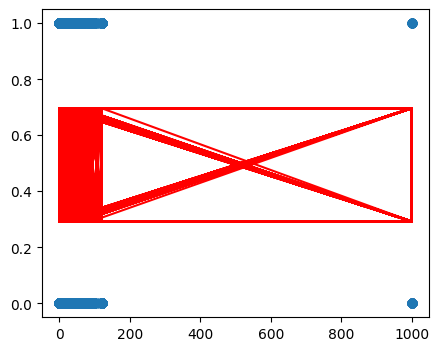

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 4))
plt.scatter(tabla_final["P1913S2"], tabla_final["P9090_2"])
plt.plot(tabla_final["P1913S2"], pred_lineal, linestyle='-', color = "red")
plt.show()

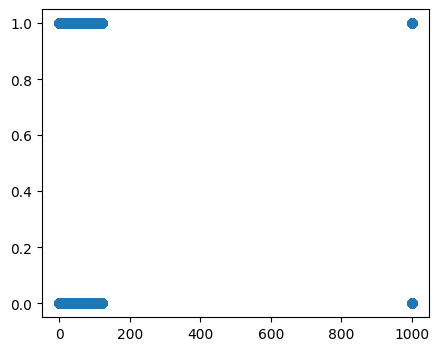

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 4))
plt.scatter(tabla_final["P1913S3"], tabla_final["P9090_2"])
# plt.plot(tabla_final["P1913S3"], pred_lineal, linestyle='-', color = "red")
plt.show()

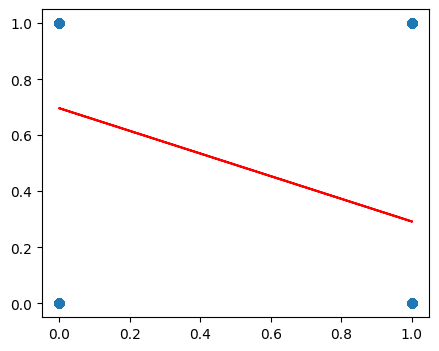

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 4))
plt.scatter(tabla_final["P5230_1"], tabla_final["P9090_2"])
plt.plot(tabla_final["P5230_1"], pred_lineal, linestyle='-', color = "red")
plt.show()

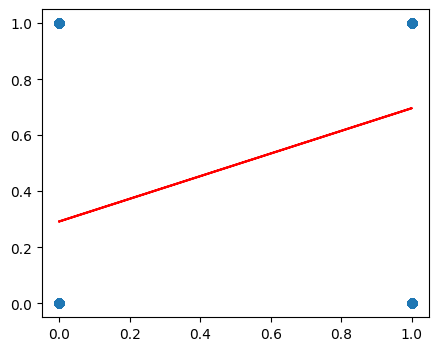

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 4))
plt.scatter(tabla_final["P5230_2"], tabla_final["P9090_2"])
plt.plot(tabla_final["P5230_2"], pred_lineal, linestyle='-', color = "red")
plt.show()

In [ ]:
X = tabla_regresion1.drop(columns = ["peso_nac"])
Y = tabla_regresion1[["peso_nac"]]